In [1]:
import torch
from torch import nn
from d2l import torch as d2l

In [23]:
def cor2d(X, K):
    w, h = K.shape
    m, n = X.shape
    Y = torch.zeros((m - w + 1, n - h + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i][j] = (X[i:i + w, j:j + h] * K).sum()
    return Y


In [24]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0, 1.0], [2.0, 3.0]])
cor2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [25]:
class Conv2D(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(kernel_size))
        self.bias = nn.Parameter(torch.ones(1))

    def forward(self, input_X):
        return cor2d(input_X, self.weight)


In [26]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])

In [27]:
K = torch.tensor([[1.0, -1.0]])

In [28]:
Y = cor2d(X, K)
Y

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])

In [31]:
conv2d = nn.LazyConv2d(1, kernel_size=(1, 2), bias=False)

X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
print(X)
print(Y)
lr = 3e-2

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward()

    conv2d.weight.data [:] -= lr * conv2d.weight.grad

    print(f'epoch {i}, loss {l.sum()}')

tensor([[[[1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.]]]])
tensor([[[[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.]]]])
epoch 0, loss 16.215572357177734
epoch 1, loss 8.050999641418457
epoch 2, loss 4.199514389038086
epoch 3, loss 2.2972893714904785
epoch 4, loss 1.310356855392456
epoch 5, loss 0.7731302976608276
epoch 6, loss 0.46797508001327515
epoch 7, loss 0.2885151505470276
epoch 8, loss 0.18014857172966003
epoch 9, loss 0.11345154792070389


In [ ]:
def comp_conv_2d(conv_2d, X_input):
    X_input = X_input.reshape(X_input.shape + (1, 1))
    Y_output = conv_2d(X_input)
    return Y_output.reshape(Y.shape[2:])




In [33]:
def pool2d(X_input, pool_size, mode='max'):
    pool_height, pool_width = pool_size
    m = X_input.shape[0]
    n = X_input.shape[1]
    Y_output = torch.zeros((m - pool_height + 1, n - pool_width + 1))

    for i in range(Y_output.shape[0]):
        for j in range(Y_output.shape[1]):
            if mode == 'max':
                Y_output[i, j] = X_input[i:i + pool_height, j:j + pool_width].max()
            elif mode == 'avg':
                Y_output[i, j] = X_input[i:i + pool_height, j:j + pool_width].mean()
    return Y_output

In [34]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

In [35]:
le_net = nn.Sequential(
    nn.Conv2d(in_channels=1, out_channels=6, kernel_size=(5, 5), padding= 2),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2)),
    nn.Conv2d(in_channels=6, out_channels=16, kernel_size=(5, 5)),
    nn.Sigmoid(),
    nn.AvgPool2d(kernel_size=(2, 2), stride=(2, 2)),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),
    nn.Sigmoid(),
    nn.Linear(120, 84),
    nn.Sigmoid(),
    nn.Linear(84, 10)

)

In [36]:
print(le_net)

Sequential(
  (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): Sigmoid()
  (2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (4): Sigmoid()
  (5): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=400, out_features=120, bias=True)
  (8): Sigmoid()
  (9): Linear(in_features=120, out_features=84, bias=True)
  (10): Sigmoid()
  (11): Linear(in_features=84, out_features=10, bias=True)
)


In [37]:
X = torch.rand(size=(1, 1, 28, 28), dtype=torch.float32)
for layer in le_net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape: \t',X.shape)

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [8]:
class LeNet(d2l.Classifier):
    def __init__(self, lr = 0.1, num_classes = 10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5, padding=2), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes)
        )

    def layer_summary(self, X_shape):
        X_input = torch.randn(X_shape)
        for layer in self.net:
            X_input = layer(X_input)
            print(layer.__class__.__name__,'output shape: \t', X_input.shape)

In [9]:
model = LeNet()
model.layer_summary((1, 1, 28, 28))

Conv2d output shape: 	 torch.Size([1, 6, 28, 28])
Sigmoid output shape: 	 torch.Size([1, 6, 28, 28])
AvgPool2d output shape: 	 torch.Size([1, 6, 14, 14])
Conv2d output shape: 	 torch.Size([1, 16, 10, 10])
Sigmoid output shape: 	 torch.Size([1, 16, 10, 10])
AvgPool2d output shape: 	 torch.Size([1, 16, 5, 5])
Flatten output shape: 	 torch.Size([1, 400])
Linear output shape: 	 torch.Size([1, 120])
Sigmoid output shape: 	 torch.Size([1, 120])
Linear output shape: 	 torch.Size([1, 84])
Sigmoid output shape: 	 torch.Size([1, 84])
Linear output shape: 	 torch.Size([1, 10])


In [5]:
def init_cnn(module):  #@save
    """Initialize weights for CNNs."""
    if type(module) == nn.Linear or type(module) == nn.Conv2d:
        nn.init.xavier_uniform_(module.weight)

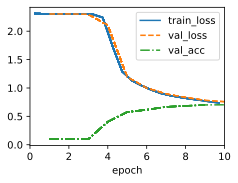

In [10]:
trainer = d2l.Trainer(max_epochs=10)
data = d2l.FashionMNIST(batch_size=128)
model = LeNet()
model.apply_init([next(iter(data.get_dataloader(True)))[0]], init_cnn)
trainer.fit(model, data)